$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 3.2

## 理论

构建响应曲面的高斯过程模型：$h(\boldsymbol{x}) \sim GP(\mu, \tau^2R(\cdot))$。暂且假定均值 $\mu$、方差 $\tau^2$ 以及相关参数 $\theta$ 均为已知。现有观测数据集 $\{(\boldsymbol{x}_i, y_i)\}_{i=1}^n$，则 $h(\boldsymbol{x})$ 的后验分布满足：

$$
h(\boldsymbol{x})|y \sim \mathcal{N}(\hat{y}(\boldsymbol{x}), s^2(\boldsymbol{x}))
$$

其中：

$$
\hat{y}(\boldsymbol{x}) = \mu + \boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}(\boldsymbol{y} - \mu\boldsymbol{1})
$$

$$
s^2(\boldsymbol{x}) = \tau^2\left[1 - \boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})\right]
$$

式中 $\boldsymbol{r}(\boldsymbol{x}) = \{R(\boldsymbol{x}-\boldsymbol{x}_i)\}_{i=1}^n$，矩阵 $\boldsymbol{R} = \{R(\boldsymbol{x}_i-\boldsymbol{x}_j)\}_{i,j=1}^n$。

我们的目标是确定试验设计方案，使得对任意属于试验区域 $\mathcal{X}$ 的自变量 $\boldsymbol{x}$，预测值 $\hat{y}(\boldsymbol{x})$ 尽可能贴近真实响应曲面 $h(\boldsymbol{x})$；经过标准化处理后，试验区域 $\mathcal{X}$ 通常为超立方体 $[0, 1]^p$。二者的接近程度可通过置信区间 $\hat{y}(\boldsymbol{x}) \pm z_{1-\alpha/2}s(\boldsymbol{x})$ 衡量，其中 $z_{1-\alpha/2}$ 为标准正态分布的上 $(1-\alpha/2)$ 分位数。因此优化目标可设定为最小化置信区间宽度 $2z_{1-\alpha/2}s(\boldsymbol{x})$。由于该宽度随自变量 $\boldsymbol{x}$ 变化，我们转而采用积分平均形式：

$$
\min_{D}\int_{\mathcal{X}} s(\boldsymbol{x})w(\boldsymbol{x})d\boldsymbol{x}
$$

式中 $w(\boldsymbol{x})$ 为权重函数，用于表征响应曲面在位置 $\boldsymbol{x}$ 处的重要程度。现阶段假定研究关注整个试验区域 $\mathcal{X}$，即区域内所有 $\boldsymbol{x}$ 的重要性均等。参数 $\tau$ 不会影响优化过程，故令 $\tau=1$。由此得到最优设计准则：最小化积分均方根误差：

$$
IRMSE(D; \theta)=\int_{\mathcal{X}}\sqrt{1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})}d\boldsymbol{x}
\tag{3.1}
$$

实际上，采用积分均方误差在数学计算上更为简便：

$$
\begin{align*}
IMSE(D; \theta)&=\int_{\mathcal{X}}\left\{1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})\right\}d\boldsymbol{x} \tag{3.2}\\
&=1-tr\left( \boldsymbol{R}^{-1}\int_{\mathcal{X}} \boldsymbol{r}(\boldsymbol{x})\boldsymbol{r}(\boldsymbol{x})'d\boldsymbol{x} \right)
\end{align*}
$$

上式中 $\mathcal{X} = [0, 1]^p$。

我们选取一个一维问题，便于直观理解设计准则。积分均方误差（IMSE）准则必须先给定相关函数及其参数才能计算。取相关函数 $R(x) = \exp(-x^2/\theta^2)$，并令 $\theta=0.1$。图 3.2 左上子图展示了包含 10 个试验点的等距设计

$$
D_1=\left\{\frac{i-1}{n-1}\right\}_{i=1}^n
$$

以及包含 10 个试验点的切比雪夫设计

$$
D_2=\left\{0.5+0.5\cos\left(\frac{\pi(i-0.5)}{n}\right)\right\}_{i=1}^n
$$

（设定 $n=10$）对应的均方根误差 RMSE（等价于缩放后后验标准差 $s(x)/\tau$）。可以看到：在试验点位置处 RMSE 取值为 0，随着预测点远离试验点，RMSE 逐渐增大。切比雪夫设计在区间边界附近分配了更多试验点，因此边界区域的 RMSE 较小，但区间中心位置的 RMSE 会变大。我们可通过计算式 (3.2) 中的积分均方误差 IMSE 对比两种设计方案。借助数值积分计算可得：$\text{IMSE}(D_1;0.1)=0.0705$，$\text{IMSE}(D_2;0.1)=0.1227$，说明等距设计表现更优。我们可以对 IMSE 准则做优化求解最优试验设计。本文在 R 语言的 optim 函数中采用无导数有限内存 BFGS（L-BFGS）优化算法，以等距设计作为优化初始值求解最优设计。最优设计 $D_3$ 绘制在同一张图的左下子图中，其积分均方误差 $\text{IMSE}(D_3;0.1)=0.0496$。不难发现，该最优设计将试验点向区间中心聚拢，致使区间边界处的 RMSE 变大，但整体的积分均方误差实现了进一步降低。

注意到

$$
\int_X \left\{1 - \boldsymbol{r}(\boldsymbol{x})'R^{-1}\boldsymbol{r}(\boldsymbol{x})\right\} dx \le \max_{x\in X} \left\{1 - \boldsymbol{r}(\boldsymbol{x})'R^{-1}\boldsymbol{r}(\boldsymbol{x})\right\}
$$

我们可以定义另一准则，即最小化最大均方误差：

$$
MMSE(D; \theta) = \max_{x\in X} \left\{1 - \boldsymbol{r}(\boldsymbol{x})'R^{-1}\boldsymbol{r}(\boldsymbol{x})\right\}
\tag{3.3}
$$

通过最小化均方误差得到的最优设计方案（$D_4$）展示于图 3.2 的右下子图中。可以发现，该设计能够将最大不确定度降至最低；相较于集成均方误差设计方案，该最优设计只是略微将采样点向边界靠拢即可实现上述效果。四种设计方案各自对应的均方误差数值同样标注在图 3.2 中。

## 实践

创建画布宽 20 英寸、高 20 英寸，将画布分为 2x2。令 theta=0.1，n=10。在 $[0,1]$ 上均匀取 301 个点作为绘图点的横坐标，令其为 test。依据 $[0,1]$ 间含端点的等距公式

$$
\left\{\frac{i-1}{n-1}\right\}_{i=1}^{n}
$$

创建 n 个点作为观测点的横坐标，令其为 D。导入 gpcrit 包，调用 gp_rmse() 函数计算该设计的均方根误差，其中观测点集为 D，参数为 theta，绘图点集为 test，将计算结果令为 sa。绘制该设计的 RMSE 图像，其中类型为 l，x 轴的标注为 x，y 轴的标注为 RMSE，大小为2 ，y 轴的范围为 c(0,.7)，大小为 2，标题为“等距设计”，大小为 4，线宽为 4。叠加观测点 (D,0)，其中点型为 16，颜色为蓝色，大小为 4。叠加文本，位置在 (0.2,0.7)，内容为 IMSE=...，大小为 4，其中的数值部分调用 imse() 函数计算，观测点集为 D，参数为 theta，保留 4 位小数，大小为 3，颜色为 2。叠加文本，位置在 (0.8,0.7)，内容为 MMSE=...，大小为 4，其中的数值部分调用 mmse() 函数计算，观测点集为 D，参数为 theta，保留 4 位小数，大小为 3，颜色为 3。

依据 $[0,1]$ 间的切比雪夫设计公式

$$
D_2=\left\{0.5+0.5\cos\left(\frac{\pi(i-0.5)}{n}\right)\right\}_{i=1}^n
$$

创建 n 个点作为观测点的横坐标，令其为 D。调用 gp_rmse() 函数计算该设计的均方根误差，其中观测点集为 D，参数为 theta，绘图点集为 test，将计算结果令为 sa。绘制该设计的 RMSE 图像，其中类型为 l，x 轴的标注为 x，y 轴的标注为 RMSE，大小为2 ，y 轴的范围为 c(0,.7)，大小为 2，标题为“切比雪夫设计”，大小为 4，线宽为 4。叠加观测点 (D,0)，其中点型为 16，颜色为蓝色，大小为 4。叠加文本，位置在 (0.2,0.7)，内容为 IMSE=...，大小为 4，其中的数值部分调用 imse() 函数计算，观测点集为 D，参数为 theta，保留 4 位小数，大小为 3，颜色为 2。叠加文本，位置在 (0.8,0.7)，内容为 MMSE=...，大小为 4，其中的数值部分调用 mmse() 函数计算，观测点集为 D，参数为 theta，保留 4 位小数，大小为 3，颜色为 3。

依据 $[0,1]$ 间不含端点的等距公式

$$
\left\{\frac{i-0.5}{n-1}\right\}_{i=1}^{n}
$$

创建 n 个点作为优化初始值，令其为 D0。调用 optim() 函数，其中初始点集为 D0，待优化的函数为 IMSE，下界为 0，上界为 1，算法为“L-BFGS-B”，优化后的列表取 par 列正是最终选定的观测点集横坐标，令其为 D。调用 gp_rmse() 函数计算该设计的均方根误差，其中观测点集为 D，参数为 theta，绘图点集为 test，将计算结果令为 sa。绘制该设计的 RMSE 图像，其中类型为 l，x 轴的标注为 x，y 轴的标注为 RMSE，大小为2 ，y 轴的范围为 c(0,.7)，大小为 2，标题为“积分均方误差最优设计”，大小为 4，线宽为 4。叠加观测点 (D,0)，其中点型为 16，颜色为蓝色，大小为 4。叠加文本，位置在 (0.2,0.7)，内容为 IMSE=...，大小为 4，其中的数值部分调用 imse() 函数计算，观测点集为 D，参数为 theta，保留 4 位小数，大小为 3，颜色为 2。叠加文本，位置在 (0.8,0.7)，内容为 MMSE=...，大小为 4，其中的数值部分调用 mmse() 函数计算，观测点集为 D，参数为 theta，保留 4 位小数，大小为 3，颜色为 3。

调用 optim() 函数，其中初始点集为 D0，待优化的函数为 MMSE，下界为 0，上界为 1，算法为“L-BFGS-B”，优化后的列表取 par 列正是最终选定的观测点集横坐标，令其为 D。调用 gp_rmse() 函数计算该设计的均方根误差，其中观测点集为 D，参数为 theta，绘图点集为 test，将计算结果令为 sa。绘制该设计的 RMSE 图像，其中类型为 l，x 轴的标注为 x，y 轴的标注为 RMSE，大小为2 ，y 轴的范围为 c(0,.7)，大小为 2，标题为“最小均方误差最优设计”，大小为 4，线宽为 4。叠加观测点 (D,0)，其中点型为 16，颜色为蓝色，大小为 4。叠加文本，位置在 (0.2,0.7)，内容为 IMSE=...，大小为 4，其中的数值部分调用 imse() 函数计算，观测点集为 D，参数为 theta，保留 4 位小数，大小为 3，颜色为 2。叠加文本，位置在 (0.8,0.7)，内容为 MMSE=...，大小为 4，其中的数值部分调用 mmse() 函数计算，观测点集为 D，参数为 theta，保留 4 位小数，大小为 3，颜色为 3。将画布还原回 1x1。

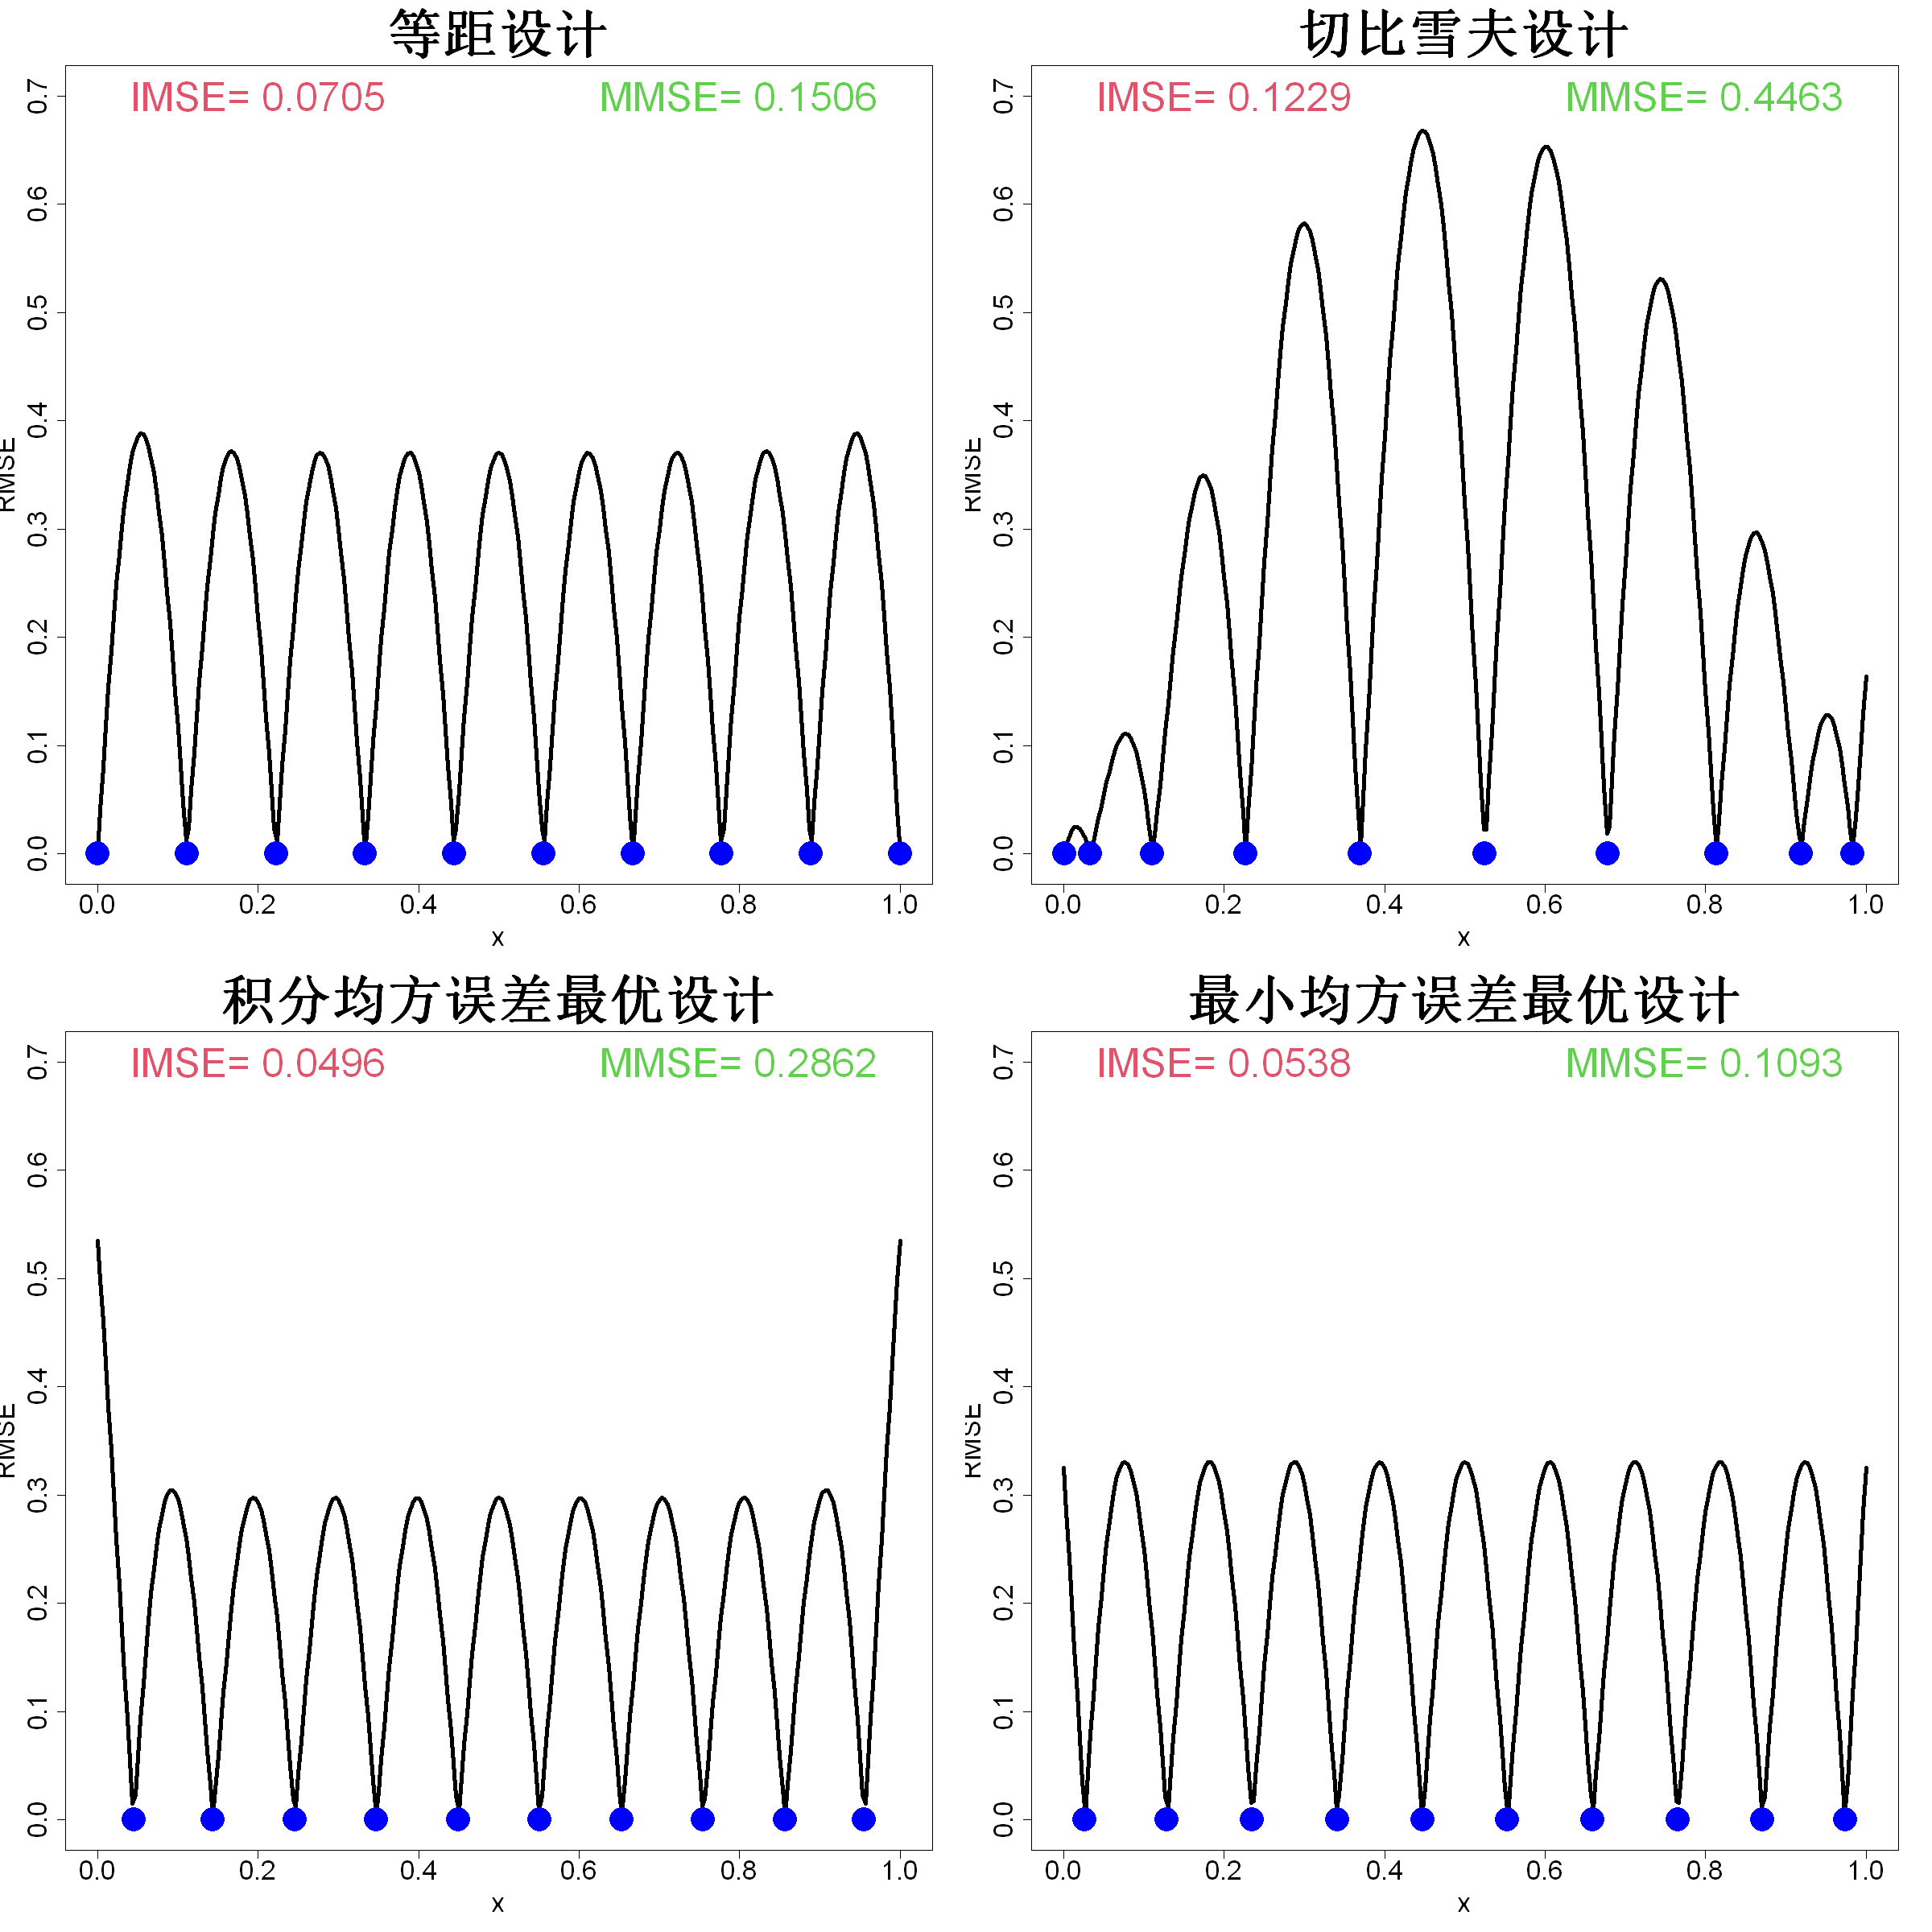

In [2]:
options(repr.plot.width=20,repr.plot.height=20)
par(mfrow=c(2,2))
theta=.1
n=10
test=seq(0,1,length=301)
D=((1:n)-1)/(n-1)
library(gpcrit)
sa=gp_rmse(D,theta,test)
plot(test,sa,type="l",xlab="x",ylab="RMSE",cex.lab=2,ylim=c(0,.7),cex.axis=2,main="等距设计",cex.main=4,lwd=4)
points(cbind(D,0),pch=16,col="blue",cex=4)
text(.2,.7,paste("IMSE=",round(imse(D,theta),4)),cex=3,col=2)
text(.8,.7,paste("MMSE=",round(mmse(D,theta),4)),cex=3,col=3)

D=.5+.5*cos((pi*(1:n)-.5)/n)
sa=gp_rmse(D,theta,test)
plot(test,sa,type="l",xlab="x",ylab="RMSE",cex.lab=2,ylim=c(0,.7),cex.axis=2,main="切比雪夫设计",cex.main=4,lwd=4)
points(cbind(D,0),pch=16,col="blue",cex=4)
text(.2,.7,paste("IMSE=",round(imse(D,theta),4)),cex=3,col=2)
text(.8,.7,paste("MMSE=",round(mmse(D,theta),4)),cex=3,col=3)

D0=((1:n)-.5)/n
D=optim(D0,function(D)imse(D,theta),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par
sa=gp_rmse(D,theta,test)
plot(test,sa,type="l",xlab="x",ylab="RMSE",cex.lab=2,ylim=c(0,.7),cex.axis=2,main="积分均方误差最优设计",cex.main=4,lwd=4)
points(cbind(D,0),pch=16,col="blue",cex=4)
text(.2,.7,paste("IMSE=",round(imse(D,theta),4)),cex=3,col=2)
text(.8,.7,paste("MMSE=",round(mmse(D,theta),4)),cex=3,col=3)

D=optim(D0,function(D)mmse(D,theta),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par
sa=gp_rmse(D,theta,test)
plot(test,sa,type="l",xlab="x",ylab="RMSE",cex.lab=2,ylim=c(0,.7),cex.axis=2,main="最小均方误差最优设计",cex.main=4,lwd=4)
points(cbind(D,0),pch=16,col="blue",cex=4)
text(.2,.7,paste("IMSE=",round(imse(D,theta),4)),cex=3,col=2)
text(.8,.7,paste("MMSE=",round(mmse(D,theta),4)),cex=3,col=3)
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$